# Stochastic Gradient Descent (SGD) trong tối ưu hóa

Notebook này tóm tắt lại kiến thức cơ bản về **Stochastic Gradient Descent (SGD)**, so sánh với **Batch Gradient Descent** và **Mini-batch Gradient Descent**, kèm ví dụ demo bằng Python.

Mục tiêu chính:

- Hiểu SGD là gì
- Biết vì sao SGD nhanh hơn Gradient Descent thường
- Thấy được SGD cập nhật tham số như thế nào
- Demo SGD cho bài toán Linear Regression đơn giản

## 1. Nhắc lại bài toán tối ưu hóa

Trong Machine Learning, ta thường muốn tìm bộ tham số tốt nhất để **loss function** nhỏ nhất.

Ví dụ:

$$
\min_{\theta} J(\theta)
$$

Trong đó:

- $\theta$: tham số cần học, ví dụ weight $w$, bias $b$
- $J(\theta)$: hàm mất mát, hay loss function
- Mục tiêu: tìm $\theta$ sao cho $J(\theta)$ nhỏ nhất

Nói đơn giản: model dự đoán sai thì loss lớn, model dự đoán đúng hơn thì loss nhỏ.

## 2. Gradient Descent là gì?

Gradient Descent cập nhật tham số theo công thức:

$$
\theta = \theta - \alpha \nabla J(\theta)
$$

Trong đó:

- $\alpha$: learning rate, tức tốc độ học
- $\nabla J(\theta)$: gradient của loss function
- Dấu trừ $-$ nghĩa là đi ngược chiều gradient để làm loss giảm xuống

Trực giác:

> Gradient chỉ hướng tăng nhanh nhất của loss. Muốn loss giảm thì ta đi ngược hướng đó.

## 3. Vấn đề của Batch Gradient Descent

**Batch Gradient Descent** dùng toàn bộ dataset để tính gradient trong mỗi lần cập nhật.

Ví dụ dataset có 100,000 dòng thì mỗi bước update phải tính trên cả 100,000 dòng.

Ưu điểm:

- Gradient ổn định hơn
- Đường đi xuống loss mượt hơn

Nhược điểm:

- Chậm nếu dataset lớn
- Mỗi lần update tốn nhiều thời gian

## 4. Stochastic Gradient Descent (SGD) là gì?

**SGD = Stochastic Gradient Descent**

Thay vì dùng toàn bộ dataset, SGD chỉ lấy **1 sample ngẫu nhiên** để cập nhật tham số ở mỗi bước.

Công thức:

$$
\theta = \theta - \alpha \nabla J_i(\theta)
$$

Trong đó:

- $J_i(\theta)$: loss của một điểm dữ liệu thứ $i$
- Mỗi bước update chỉ dựa trên một sample

Điểm quan trọng:

> SGD nhanh hơn vì update liên tục, nhưng đường đi sẽ nhiễu hơn và thường zigzag.

## 5. Trực giác dễ hiểu

Hãy tưởng tượng bạn đang đi xuống núi trong sương mù.

**Batch Gradient Descent** giống như mỗi bước bạn nhìn toàn bộ địa hình rồi mới quyết định đi hướng nào. Cách này chắc hơn nhưng chậm.

**SGD** giống như mỗi bước bạn chỉ nhìn một điểm gần mình rồi đi ngay. Cách này nhanh hơn nhưng đường đi có thể rung lắc, không mượt.

**Mini-batch Gradient Descent** là cách ở giữa: mỗi bước nhìn một nhóm nhỏ dữ liệu, ví dụ 32 hoặc 64 dòng.

## 6. So sánh Batch GD, SGD và Mini-batch GD

| Loại | Dữ liệu dùng mỗi lần update | Ưu điểm | Nhược điểm |
|---|---:|---|---|
| Batch Gradient Descent | Toàn bộ dataset | Ổn định, ít nhiễu | Chậm |
| Stochastic Gradient Descent | 1 sample | Nhanh, update liên tục | Nhiễu, zigzag |
| Mini-batch Gradient Descent | Một batch nhỏ, ví dụ 32/64 | Cân bằng nhất | Cần chọn batch size |

Trong thực tế, đặc biệt là Deep Learning, người ta thường dùng **Mini-batch Gradient Descent** nhiều nhất.

## 7. Demo: Linear Regression với SGD

Ta sẽ tạo dữ liệu giả lập theo công thức:

$$
y = 3x + 2 + noise
$$

Mục tiêu của model là học lại gần đúng:

- Weight $w \approx 3$
- Bias $b \approx 2$

Model dự đoán:

$$
\hat{y} = wx + b
$$

Loss dùng Mean Squared Error:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

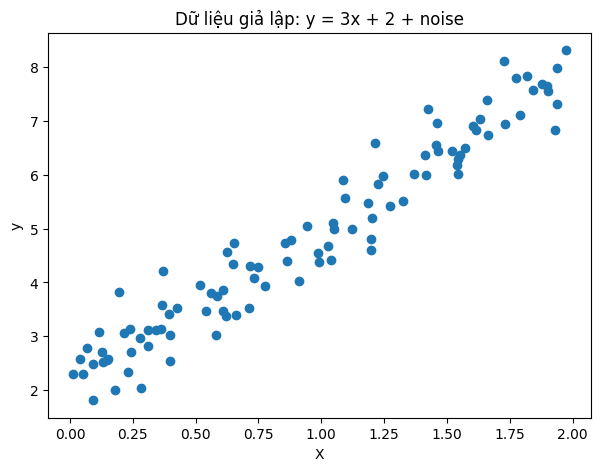

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Để kết quả random có thể lặp lại
np.random.seed(42)

# Tạo dữ liệu giả lập
n = 100
X = 2 * np.random.rand(n, 1)
y = 3 * X + 2 + np.random.randn(n, 1) * 0.5

# Vẽ dữ liệu
plt.figure(figsize=(7, 5))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dữ liệu giả lập: y = 3x + 2 + noise")
plt.show()

## 8. Viết SGD từ đầu bằng NumPy

Ta sẽ tự cập nhật $w$ và $b$ theo từng sample.

Với một sample:

$$
\hat{y}_i = wx_i + b
$$

Loss của sample đó:

$$
L_i = (y_i - \hat{y}_i)^2
$$

Gradient theo $w$:

$$
\frac{\partial L_i}{\partial w} = -2x_i(y_i - \hat{y}_i)
$$

Gradient theo $b$:

$$
\frac{\partial L_i}{\partial b} = -2(y_i - \hat{y}_i)
$$

Cập nhật:

$$
w = w - \alpha \frac{\partial L_i}{\partial w}
$$

$$
b = b - \alpha \frac{\partial L_i}{\partial b}
$$

In [4]:
# Khởi tạo tham số ngẫu nhiên
w = np.random.randn(1)
b = np.random.randn(1)

learning_rate = 0.01
epochs = 50
loss_history = []

for epoch in range(epochs):
    # Shuffle dữ liệu mỗi epoch để SGD đúng nghĩa random hơn
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    for i in range(n):
        xi = X_shuffled[i]
        yi = y_shuffled[i]
        
        # Dự đoán
        y_pred = w * xi + b
        
        # Gradient của loss theo w và b
        grad_w = -2 * xi * (yi - y_pred)
        grad_b = -2 * (yi - y_pred)
        
        # Cập nhật tham số
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b
    
    # Tính loss trên toàn bộ dataset sau mỗi epoch để theo dõi
    y_pred_all = w * X + b
    mse = np.mean((y - y_pred_all) ** 2)
    loss_history.append(mse)

print("Weight học được:", w[0])
print("Bias học được:", b[0])
print("MSE cuối:", loss_history[-1])

Weight học được: 2.8949146015222116
Bias học được: 2.109046570111259
MSE cuối: 0.20179615844679433


## 9. Vẽ loss giảm qua từng epoch

Nếu SGD hoạt động tốt, loss sẽ có xu hướng giảm dần qua các epoch.

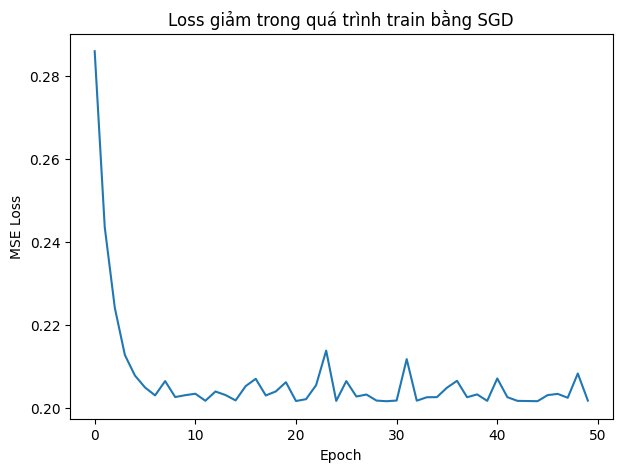

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss giảm trong quá trình train bằng SGD")
plt.show()

## 10. Vẽ đường Linear Regression học được

Sau khi train, model học được một đường thẳng gần với dữ liệu ban đầu.

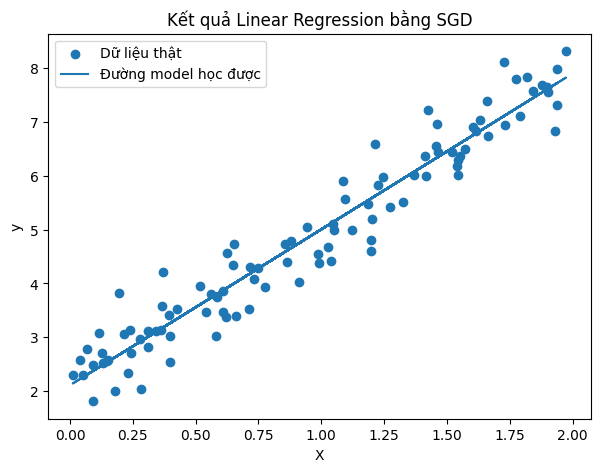

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, label="Dữ liệu thật")
plt.plot(X, w * X + b, label="Đường model học được")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Kết quả Linear Regression bằng SGD")
plt.legend()
plt.show()

## 11. Demo thêm: So sánh SGD và Batch Gradient Descent

Bây giờ ta viết thêm Batch Gradient Descent để so sánh.

Khác biệt chính:

- Batch GD tính gradient trên toàn bộ dataset rồi mới update
- SGD update từng sample một

In [7]:
# Batch Gradient Descent
w_batch = np.random.randn(1)
b_batch = np.random.randn(1)

learning_rate = 0.01
epochs = 50
batch_loss_history = []

for epoch in range(epochs):
    y_pred = w_batch * X + b_batch
    
    grad_w = -2 * np.mean(X * (y - y_pred))
    grad_b = -2 * np.mean(y - y_pred)
    
    w_batch = w_batch - learning_rate * grad_w
    b_batch = b_batch - learning_rate * grad_b
    
    mse = np.mean((y - (w_batch * X + b_batch)) ** 2)
    batch_loss_history.append(mse)

print("Batch GD - Weight:", w_batch[0])
print("Batch GD - Bias:", b_batch[0])
print("Batch GD - MSE cuối:", batch_loss_history[-1])

Batch GD - Weight: 2.1025245293584125
Batch GD - Bias: 2.13208937267624
Batch GD - MSE cuối: 0.9222312332770001


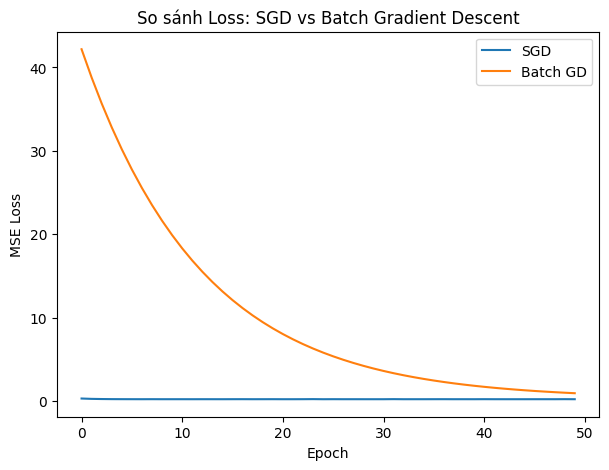

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(loss_history, label="SGD")
plt.plot(batch_loss_history, label="Batch GD")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("So sánh Loss: SGD vs Batch Gradient Descent")
plt.legend()
plt.show()

## 12. Nhận xét kết quả

Một số điểm cần nhớ:

- SGD cập nhật tham số rất nhiều lần trong một epoch vì mỗi sample đều update một lần.
- Batch GD chỉ update một lần trong một epoch.
- SGD thường giảm loss nhanh hơn lúc đầu, nhưng đường loss có thể nhiễu hơn.
- Batch GD ổn định hơn nhưng có thể chậm hơn nếu dataset lớn.
- Mini-batch GD là lựa chọn thực tế nhất trong Machine Learning và Deep Learning.

## 13. Mini-batch Gradient Descent là gì?

Mini-batch Gradient Descent dùng một nhóm nhỏ dữ liệu để update.

Ví dụ nếu batch size = 16, mỗi lần update dùng 16 sample.

Công thức tổng quát:

$$
\theta = \theta - \alpha \nabla J_{batch}(\theta)
$$

Mini-batch GD cân bằng giữa:

- Tốc độ của SGD
- Sự ổn định của Batch GD

Trong thực tế, các thư viện như PyTorch và TensorFlow thường dùng mini-batch.

In [9]:
# Mini-batch Gradient Descent demo
w_mini = np.random.randn(1)
b_mini = np.random.randn(1)

learning_rate = 0.01
epochs = 50
batch_size = 16
mini_loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    for start in range(0, n, batch_size):
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        
        y_pred = w_mini * X_batch + b_mini
        
        grad_w = -2 * np.mean(X_batch * (y_batch - y_pred))
        grad_b = -2 * np.mean(y_batch - y_pred)
        
        w_mini = w_mini - learning_rate * grad_w
        b_mini = b_mini - learning_rate * grad_b
    
    mse = np.mean((y - (w_mini * X + b_mini)) ** 2)
    mini_loss_history.append(mse)

print("Mini-batch GD - Weight:", w_mini[0])
print("Mini-batch GD - Bias:", b_mini[0])
print("Mini-batch GD - MSE cuối:", mini_loss_history[-1])

Mini-batch GD - Weight: 2.7416547284064436
Mini-batch GD - Bias: 2.272733687483598
Mini-batch GD - MSE cuối: 0.20977330789631718


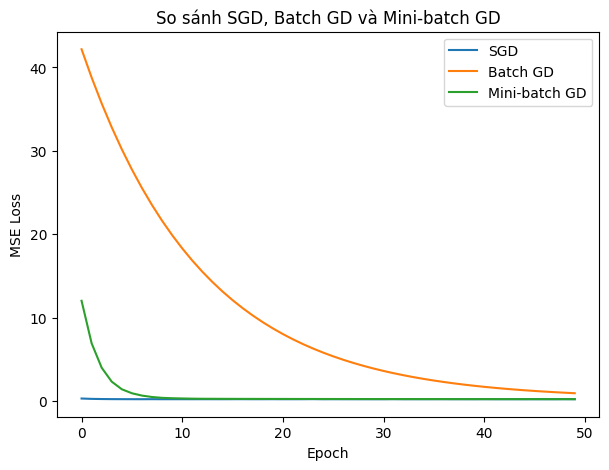

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(loss_history, label="SGD")
plt.plot(batch_loss_history, label="Batch GD")
plt.plot(mini_loss_history, label="Mini-batch GD")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("So sánh SGD, Batch GD và Mini-batch GD")
plt.legend()
plt.show()

## 14. Kết luận ngắn gọn

**Gradient Descent** là phương pháp tối ưu hóa dùng gradient để cập nhật tham số theo hướng làm loss giảm.

**SGD** là phiên bản cập nhật theo từng sample ngẫu nhiên:

- Nhanh hơn Batch Gradient Descent
- Phù hợp với dataset lớn
- Nhưng đường đi nhiễu hơn

**Mini-batch Gradient Descent** là cách dùng phổ biến nhất trong thực tế vì cân bằng giữa tốc độ và độ ổn định.

Ghi nhớ nhanh:

> Batch GD = chậm nhưng ổn định  
> SGD = nhanh nhưng rung lắc  
> Mini-batch GD = thực tế dùng nhiều nhất

## 15. Bài tập tự luyện

### Bài 1
Thay đổi `learning_rate` thành `0.001`, `0.05`, `0.1` và quan sát loss thay đổi như thế nào.

### Bài 2
Thay đổi số `epochs` thành `10`, `100`, `200` và quan sát model học tốt hơn hay không.

### Bài 3
Thay đổi `batch_size` trong Mini-batch GD thành `4`, `32`, `64` và so sánh loss.

### Bài 4
Thử tạo dữ liệu mới theo công thức:

$$
y = 5x - 1 + noise
$$

Sau đó xem model có học được $w \approx 5$ và $b \approx -1$ không.